<a href="https://colab.research.google.com/github/Olu-David/Loan_Problem_Dataset/blob/main/Loan_Problem_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

Unzipping the folder

In [33]:
!unzip /content/predictiondataset.zipy

unzip:  cannot find or open /content/predictiondataset.zipy, /content/predictiondataset.zipy.zip or /content/predictiondataset.zipy.ZIP.


Loading the dataset

In [34]:
train_df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
test_df = pd.read_csv('/content/test_Y3wMUE5_7gLdaTN.csv')

In [35]:
#Print the dataframes to see the data
train_df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [36]:
#Checking for empty or missing value
train_df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [37]:
# We fill in the empty values
train_df['Gender'].fillna(train_df['Gender'].mode()[0], inplace=True)
train_df['Married'].fillna(train_df['Married'].mode()[0], inplace=True)
train_df['Dependents'].fillna(train_df['Dependents'].mode()[0], inplace=True)
train_df['Self_Employed'].fillna(train_df['Self_Employed'].mode()[0], inplace=True)
train_df['Credit_History'].fillna(train_df['Credit_History'].mode()[0], inplace=True)
train_df['LoanAmount'].fillna(train_df['LoanAmount'].median(), inplace=True)
train_df['Loan_Amount_Term'].fillna(train_df['Loan_Amount_Term'].mode()[0], inplace=True)

/tmp/ipykernel_912/2434376684.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Gender'].fillna(train_df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_912/2434376684.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [38]:
#Checking for empty or missing value
train_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [39]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


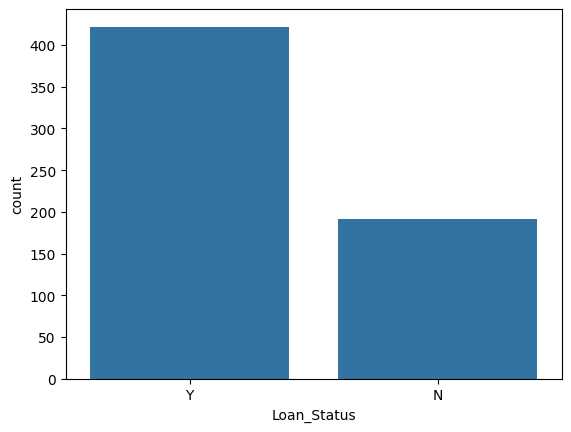

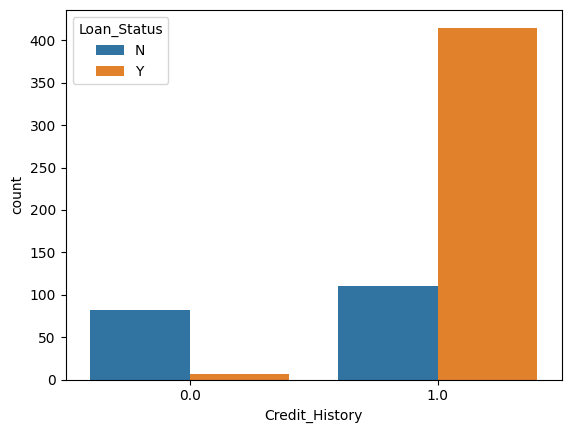

In [40]:
# First plot: Overall Loan Status breakdown
sns.countplot(x='Loan_Status', data=train_df)
plt.show()

# Second plot: Credit History split by Loan Status (Notice the comma added!)
sns.countplot(x='Credit_History', hue='Loan_Status', data=train_df)
plt.show()

Future Engineering

In [41]:
train_df['Total_Income'] = train_df['ApplicantIncome'] + train_df['CoapplicantIncome']
train_df['Income_to_Loan_Ratio'] = train_df['Total_Income'] / train_df['LoanAmount']
train_df['Loan_EMI'] = train_df['LoanAmount'] / train_df['Loan_Amount_Term']
train_df['IncomeLog'] = np.log(train_df['ApplicantIncome'])
train_df['LoanAmountLog'] = np.log(train_df['LoanAmount'])


In [42]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Income_to_Loan_Ratio,Loan_EMI,IncomeLog,LoanAmountLog
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,45.695312,0.355556,8.674026,4.852030
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,47.585938,0.355556,8.430109,4.852030
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,45.454545,0.183333,8.006368,4.189655
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,41.175000,0.333333,7.856707,4.787492
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,42.553191,0.391667,8.699515,4.948760


Changing Text Words into Machine Language Using Label Encoder

In [43]:
le= LabelEncoder()

In [44]:
# Make sure 'Dependents' is in this list!
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

le = LabelEncoder()
for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])

In [45]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Income_to_Loan_Ratio,Loan_EMI,IncomeLog,LoanAmountLog
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,45.695312,0.355556,8.674026,4.852030
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,47.585938,0.355556,8.430109,4.852030
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,45.454545,0.183333,8.006368,4.189655
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,41.175000,0.333333,7.856707,4.787492
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,42.553191,0.391667,8.699515,4.948760


In [46]:
# 1. Separate your features (X) and your target (y)
X = train_df.drop(columns=['Loan_Status', 'Loan_ID'])
y = train_df['Loan_Status']

# 2. STEP ONE: Split your data FIRST (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. STEP TWO: Initialize your scaler
scaler = StandardScaler()

# List of ALL continuous numerical columns (including your new engineered ones!)
numerical_cols = [
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
    'Loan_Amount_Term', 'Total_Income', 'Income_to_Loan_Ratio',
    'Loan_EMI', 'IncomeLog', 'LoanAmountLog'
]

# 4. STEP THREE: Fit AND transform the TRAIN set only (using .loc)
X_train.loc[:, numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# 5. STEP FOUR: Transform the TEST set using the training stats (using .loc)
X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])

/tmp/ipykernel_912/795608040.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 8.39146643e-02 -4.29337897e-01  1.26095184e-01 -5.76969715e-01
 -2.25521627e-01  2.40046880e+00 -3.66067118e-01 -3.60668011e-01
 -3.16800271e-01  6.75791714e-01 -3.67216215e-02  1.05004924e-01
 -4.35749336e-01 -3.02965061e-01  1.27107516e-01  2.02421856e+00
  1.23814240e+00 -1.26987933e-01 -1.55164520e-01 -1.51283912e-01
 -8.58229419e-01  2.80813329e-01 -2.55554157e-01 -2.37500894e-01
  9.27525054e-01  7.52560259e-01 -4.98176505e-01 -8.92986167e-01
 -3.94243705e-01 -1.86040660e-01 -2.95710011e-01 -3.76190442e-01
 -2.53529492e-01  2.69508950e-01 -9.32435176e-02 -3.49701076e-01
 -3.51725741e-01  5.16855516e-01  5.27010799e-02 -5.54867123e-01
 -3.75684276e-01 -3.80745938e-01 -3.37890531e-01  5.84376305e-02
 -2.55722879e-01  2.25317854e-03  4.77543272e-01 -6.75334687e-01
  1.31663012e-01 -9.64492371e-02 -4.89740401e-01 -2.02744146e-01
 

Calling Logistic Regression

In [47]:
# 1. Initialize the model
lr = LogisticRegression()

# 2. STUDY PHASE: Train the model on your training data
lr.fit(X_train, y_train)

# 3. EXAM PHASE: Make predictions on your test data
y_pred_lr = lr.predict(X_test)

# 4. GRADING PHASE: Check the accuracy
accuracy_lr = metrics.accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

# 5. View the Confusion Matrix
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 78.05%

Confusion Matrix:
[[18 25]
 [ 2 78]]


Random forest

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Initialize and train the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 2. Make predictions (classes and probabilities)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities needed for ROC-AUC

# 3. Check Accuracy
accuracy_rf = metrics.accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

# 4. Check ROC-AUC Score (The honest grading metric)
roc_score_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC-AUC Score: {roc_score_rf:.4f}")

Random Forest Accuracy: 79.67%
Random Forest ROC-AUC Score: 0.7529
